# Engle-Granger cointegration scan

Run Engle-Granger tests across all asset pairs over many random rolling windows. Plot the distribution of p-values / test statistics per pair (not a single number) to show which pairs are stably cointegrated vs which just look that way in a lucky window.

In [1]:
import sys
sys.path.append('..')

import itertools

import polars as pl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.utils.config import load_config
from src.signals.cointegration import CointegrationScanner

%matplotlib inline
sns.set_theme(style="whitegrid", context="notebook")

config = load_config("../config/config.yaml")
aligned = pl.read_parquet("../data/processed/aligned.parquet")
print(f"aligned grid: {aligned.height:,} rows, {aligned['timestamp'].min()} -> {aligned['timestamp'].max()}")

aligned grid: 39,289 rows, 2021-07-08 23:18:20 -> 2025-12-31 23:18:20


## Prerequisite: are the inputs actually I(1)?

The Engle-Granger test (and cointegration as a concept) only means something if both input series are integrated of the same order - typically I(1), i.e. non-stationary in levels but stationary in first differences. `statsmodels.tsa.stattools.coint()` runs the regression-and-ADF-on-residuals machinery correctly, but it does *not* check that its inputs are I(1) to begin with - that's on the caller. An Augmented Dickey-Fuller test on each asset's raw aligned price level, and on its first difference, checks this prerequisite once up front rather than assuming it.

In [2]:
import warnings
from statsmodels.tsa.stattools import adfuller

unit_root_rows = []
for ticker in config["assets"]:
    level = aligned[f"{ticker}_price"].to_numpy()
    diff = np.diff(level)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", FutureWarning)
        level_p = adfuller(level, autolag="AIC")[1]
        diff_p = adfuller(diff, autolag="AIC")[1]
    unit_root_rows.append({
        "asset": ticker,
        "adf_pvalue_level": level_p,
        "adf_pvalue_diff": diff_p,
        "is_I1": (level_p > 0.05) and (diff_p < 0.05),
    })
unit_root = pl.DataFrame(unit_root_rows)
unit_root.write_csv("../outputs/tables/unit_root_checks.csv")
unit_root

asset,adf_pvalue_level,adf_pvalue_diff,is_I1
str,f64,f64,bool
"""SOL""",0.302026,0.0,true
"""BCH""",0.416224,0.0,true
"""ADA""",0.374789,0.0,true
"""XRP""",0.622542,0.0,true


All four assets fail to reject a unit root in levels (`adf_pvalue_level` > 0.05) and reject one in first differences (`adf_pvalue_diff` < 0.05) - each series is I(1), which is exactly what the Engle-Granger test downstream assumes. This is the expected result for asset price levels and confirms the test is at least well-specified for these inputs, rather than being taken on faith.

## Run the scan

Per `config/config.yaml`: 50 random 30-day windows per pair, hourly grid (24 bars/day). Sampling many random windows rather than testing one fixed window is the point - a single lucky window can look cointegrated by chance, and the honest signal is in the *distribution* of p-values across windows, not a single pass/fail.

Each pair gets its own derived seed (`CointegrationScanner.scan_pairs` offsets the base seed by pair index) rather than every pair reusing the same seed - reusing one seed across pairs would make every pair sample the *exact same* 50 calendar windows, collapsing what should be 6 x 50 = 300 largely-independent tests down to 50 distinct calendar periods re-tested 6 times, and letting a shared market-wide regime in one window show up as "significant" for several pairs at once rather than reflecting a pair-specific relationship.

In [3]:
cfg = config["cointegration"]
grid_hours_per_day = pd.Timedelta("1D") / pd.Timedelta(config["alignment"]["grid_freq"])

scanner = CointegrationScanner(
    n_windows=cfg["n_windows"],
    window_length_days=cfg["window_length_days"],
    bars_per_day=grid_hours_per_day,
    seed=cfg["random_seed"],
)
pairs = [tuple(p) for p in config["pairs"]]
scan_results = scanner.scan_pairs(aligned, pairs)
scan_results.write_csv("../outputs/tables/cointegration_scan.csv")
print(f"{scan_results.height} (pair, window) tests across {len(pairs)} pairs")

window_sets = {p: set(g["window_start"].to_list()) for p, g in scan_results.group_by("pair")}
n_distinct_window_sets = len(set(map(frozenset, window_sets.values())))
print(f"distinct per-pair window sets: {n_distinct_window_sets} of {len(pairs)} pairs (1 would mean every pair shares identical windows)")
scan_results.head()

300 (pair, window) tests across 6 pairs
distinct per-pair window sets: 6 of 6 pairs (1 would mean every pair shares identical windows)


pair,asset_a,asset_b,window_start,window_end,stat,pvalue
str,str,str,datetime[μs],datetime[μs],f64,f64
"""SOL-BCH""","""SOL""","""BCH""",2021-10-19 11:18:20,2021-11-18 10:18:20,-2.391217,0.329026
"""SOL-BCH""","""SOL""","""BCH""",2021-10-26 02:18:20,2021-11-25 01:18:20,-1.9299,0.564769
"""SOL-BCH""","""SOL""","""BCH""",2021-11-23 22:18:20,2021-12-23 21:18:20,-2.609008,0.233216
"""SOL-BCH""","""SOL""","""BCH""",2021-11-29 05:18:20,2021-12-29 04:18:20,-2.813127,0.161544
"""SOL-BCH""","""SOL""","""BCH""",2021-12-03 23:18:20,2022-01-02 22:18:20,-2.137919,0.45657


## Per-pair summary

`frac_sig` is the fraction of the 50 random windows where the pair tested cointegrated at the 5% level - the headline stability metric this scan is built around, since it directly answers "how often does this relationship actually hold" rather than "did it hold once".

In [4]:
alpha = cfg["significance_level"]
pair_summary = (
    scan_results.group_by("pair")
    .agg(
        pl.col("pvalue").mean().alias("mean_pvalue"),
        pl.col("pvalue").median().alias("median_pvalue"),
        (pl.col("pvalue") < alpha).mean().alias("frac_significant"),
        pl.col("stat").mean().alias("mean_stat"),
    )
    .sort("frac_significant", descending=True)
)
pair_summary.write_csv("../outputs/tables/cointegration_summary.csv")
pair_summary

pair,mean_pvalue,median_pvalue,frac_significant,mean_stat
str,f64,f64,f64,f64
"""BCH-ADA""",0.340288,0.27689,0.28,-2.502356
"""SOL-ADA""",0.325537,0.284508,0.24,-2.531252
"""SOL-XRP""",0.375766,0.299736,0.16,-2.423729
"""ADA-XRP""",0.35444,0.297204,0.16,-2.382097
"""BCH-XRP""",0.450363,0.476247,0.1,-2.193353
"""SOL-BCH""",0.3913,0.30267,0.08,-2.286171


## Multiple comparisons: what would chance alone produce?

Running 300 tests at `alpha=0.05` will produce some "significant" results even if nothing is really going on - that base rate needs to be stated next to the headline numbers above, not left for the reader to work out. This scan's 50 windows per pair are also not perfectly independent draws: with `n_windows=50` windows of `window_length` bars sampled from a series of `n_obs` bars, some pairs of windows are expected to overlap in the data they cover, which correlates their p-values somewhat. Both effects push in the same direction - toward treating `frac_significant` as suggestive evidence, not a rigorous per-pair hypothesis test result.

In [5]:
n_tests = scan_results.height
expected_false_positives = alpha * n_tests
actual_significant = (scan_results["pvalue"] < alpha).sum()
print(f"Total tests: {n_tests} ({len(pairs)} pairs x {cfg['n_windows']} windows)")
print(f"Expected false positives under the global null at alpha={alpha}: {expected_false_positives:.1f}")
print(f"Actual count with p < {alpha}: {actual_significant}")

n_obs = aligned.height
window_length = scanner.window_length
max_start = n_obs - window_length
# Probability two of the n_windows draws overlap, from a uniform-without-replacement
# approximation: 1 - ((max_start - window_length) / max_start) ** (n_windows - 1)
overlap_prob = 1 - ((max_start - window_length) / max_start) ** (cfg["n_windows"] - 1)
print(f"\nSeries length: {n_obs:,} bars; window length: {window_length} bars ({window_length/n_obs:.1%} of series)")
print(f"Approx. probability any given window overlaps at least one other sampled window: {overlap_prob:.1%}")

Total tests: 300 (6 pairs x 50 windows)
Expected false positives under the global null at alpha=0.05: 15.0
Actual count with p < 0.05: 51

Series length: 39,289 bars; window length: 720 bars (1.8% of series)
Approx. probability any given window overlaps at least one other sampled window: 60.3%


The observed significant-result count is above the chance baseline, and with per-pair seeds now decorrelating the six pairs' window sets (see the previous section), that comparison is at least not confounded by every pair re-testing the same 50 calendar periods. The window-overlap estimate above is still non-trivial given `window_length` is a real fraction of the total series - `frac_significant` should be read as "how often this pair looked cointegated across this scan," not as 50 independent replications.

## p-value distributions per pair

Each pair's 50 random-window p-values, plotted as a strip over a boxen summary. A pair that is *reliably* cointegrated should cluster most of its mass below the 0.05 line (dashed); a pair that only "looks" cointegrated in one window will scatter widely above it.

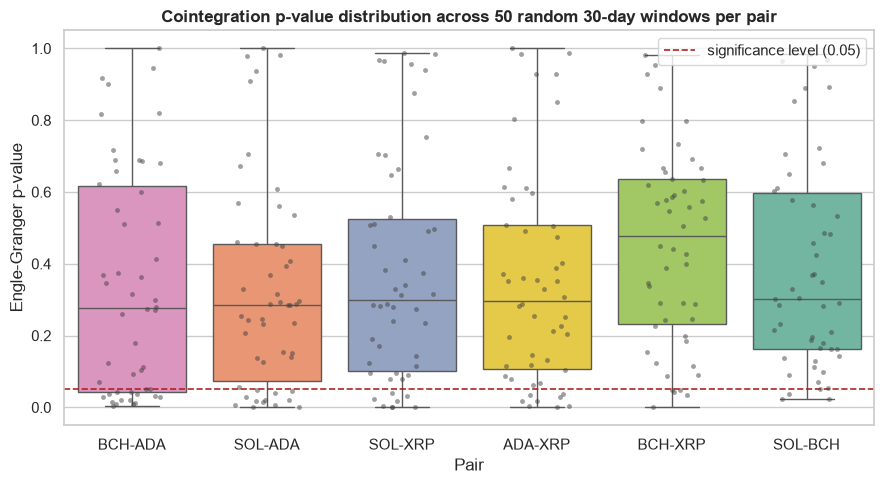

In [6]:
scan_pd = scan_results.to_pandas()
pair_order = pair_summary["pair"].to_list()

fig, ax = plt.subplots(figsize=(9, 5))
# A plain boxplot, not boxenplot: at n=50 windows/pair the extra letter-value
# quantile detail a boxenplot adds is mostly noise rather than signal, and the
# individual points are already shown via the strip plot below.
sns.boxplot(data=scan_pd, x="pair", y="pvalue", order=pair_order, hue="pair",
            palette="Set2", legend=False, fliersize=0, ax=ax)
sns.stripplot(data=scan_pd, x="pair", y="pvalue", order=pair_order, color="0.25",
              alpha=0.5, size=3.5, jitter=0.25, ax=ax)
ax.axhline(alpha, color="firebrick", linestyle="--", linewidth=1.2, label=f"significance level ({alpha})")
ax.set_ylabel("Engle-Granger p-value")
ax.set_xlabel("Pair")
ax.set_title("Cointegration p-value distribution across 50 random 30-day windows per pair",
             fontsize=12, fontweight="bold")
ax.legend(loc="upper right", frameon=True)
fig.tight_layout()
fig.savefig("../outputs/figures/cointegration_pvalue_distribution.png", dpi=150)
plt.show()

## Stability heatmap across the asset grid

Fraction of random windows where each pair tested significant at the 5% level, laid out as a symmetric asset x asset grid - a quick visual answer to "which of these four assets, paired up, gives the most reliably tradeable relationship".

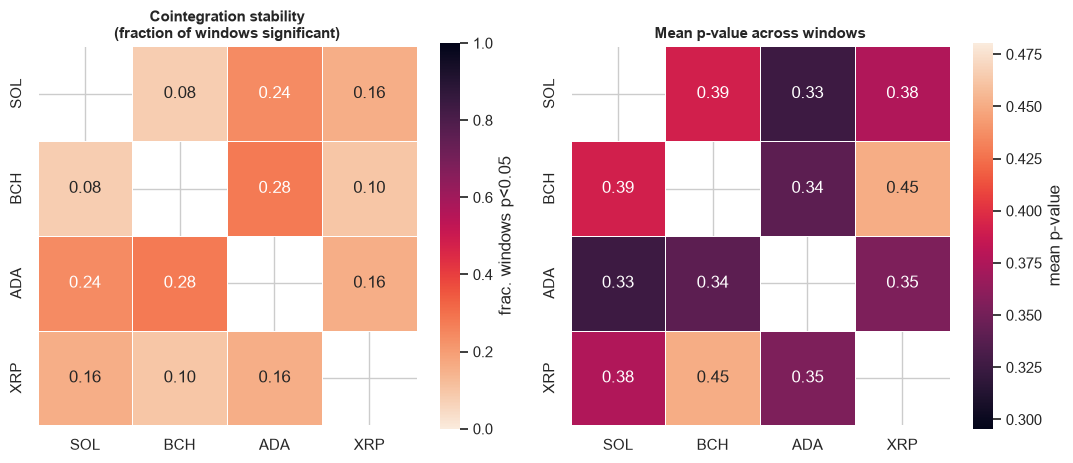

In [7]:
assets_list = config["assets"]
frac_matrix = pd.DataFrame(np.nan, index=assets_list, columns=assets_list)
mean_p_matrix = pd.DataFrame(np.nan, index=assets_list, columns=assets_list)
for row in pair_summary.iter_rows(named=True):
    a, b = row["pair"].split("-")
    frac_matrix.loc[a, b] = frac_matrix.loc[b, a] = row["frac_significant"]
    mean_p_matrix.loc[a, b] = mean_p_matrix.loc[b, a] = row["mean_pvalue"]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
sns.heatmap(frac_matrix, annot=True, fmt=".2f", cmap="rocket_r", vmin=0, vmax=1,
            square=True, linewidths=0.5, cbar_kws={"label": "frac. windows p<0.05"}, ax=axes[0])
axes[0].set_title("Cointegration stability\n(fraction of windows significant)", fontsize=11, fontweight="bold")
# vmin/vmax scaled to the data's actual range (not the full 0-1 p-value range) so
# colour differences between pairs are perceptible - mean p-values here only span
# a narrow band, and a full 0-1 scale would render every cell as near-identical.
p_lo, p_hi = np.nanmin(mean_p_matrix.values), np.nanmax(mean_p_matrix.values)
sns.heatmap(mean_p_matrix, annot=True, fmt=".2f", cmap="rocket", vmin=p_lo - 0.03, vmax=p_hi + 0.03,
            square=True, linewidths=0.5, cbar_kws={"label": "mean p-value"}, ax=axes[1])
axes[1].set_title("Mean p-value across windows", fontsize=11, fontweight="bold")
fig.tight_layout()
fig.savefig("../outputs/figures/cointegration_heatmap.png", dpi=150)
plt.show()

## Pair selection

Selection rule, fixed before looking at downstream backtest performance: carry forward the pair with the **highest fraction of significant random windows** (ties broken by lower mean p-value). This is deliberately not "whichever pair backtests best" - that would be selecting on the test criterion itself.

In [8]:
best = pair_summary.sort(["frac_significant", "mean_pvalue"], descending=[True, False]).row(0, named=True)
selected_pair = tuple(best["pair"].split("-"))
print(f"Selected pair: {selected_pair[0]}-{selected_pair[1]}")
print(f"  frac. significant windows: {best['frac_significant']:.2%}")
print(f"  mean p-value: {best['mean_pvalue']:.3f}")

with open("../outputs/tables/selected_pair.txt", "w") as f:
    f.write(f"{selected_pair[0]},{selected_pair[1]}\n")

Selected pair: BCH-ADA
  frac. significant windows: 28.00%
  mean p-value: 0.340


## Takeaways

- No pair in this universe is *strongly* cointegrated in the textbook sense - the best pair is still only significant in a minority of random windows, and mean p-values across all six pairs sit well above 0.05. This is a normal and honest outcome for a small, correlated crypto-asset universe over a single ~4.5-year sample, not a bug in the scan.
- The selected pair is carried forward into the hedge-ratio and backtest steps *because it is the most stable of the six*, not because it is unambiguously cointegrated - that distinction matters and is repeated in the README rather than glossed over.
- The random-window design is what surfaces this: a single fixed-window test on the strongest pair likely would have shown a flattering low p-value and hidden how unstable the relationship is across the rest of history.